In [1]:
import os
import cv2
import numpy as np

# === SET THESE PATHS ===
input_rgb_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\TRUE color"
green_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\GREEN"
nir_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\NIR"

# Create output folders if they don't exist
os.makedirs(green_folder, exist_ok=True)
os.makedirs(nir_folder, exist_ok=True)

# Resize for consistency (optional)
IMG_SIZE = 256

# Sort files and assign years from 2015 to 2024
image_files = sorted([
    f for f in os.listdir(input_rgb_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

years = list(range(2015, 2015 + len(image_files)))

for filename, year in zip(image_files, years):
    path = os.path.join(input_rgb_folder, filename)
    image = cv2.imread(path)

    if image is None:
        print(f"Skipping {filename} (unable to read).")
        continue

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Extract Green band
    green_band = image[:, :, 1]

    # Estimate NIR using RGB approximation
    nir_band = (0.3 * image[:, :, 2] + 0.3 * image[:, :, 1] + 0.4 * image[:, :, 0]).astype(np.uint8)

    # Save with new consistent filenames
    green_filename = f"rameshwaram_{year}_green.jpg"
    nir_filename = f"rameshwaram_{year}_nir.jpg"

    cv2.imwrite(os.path.join(green_folder, green_filename), green_band)
    cv2.imwrite(os.path.join(nir_folder, nir_filename), nir_band)

    print(f"Saved Green: {green_filename}, NIR: {nir_filename}")


Saved Green: rameshwaram_2015_green.jpg, NIR: rameshwaram_2015_nir.jpg
Saved Green: rameshwaram_2016_green.jpg, NIR: rameshwaram_2016_nir.jpg
Saved Green: rameshwaram_2017_green.jpg, NIR: rameshwaram_2017_nir.jpg
Saved Green: rameshwaram_2018_green.jpg, NIR: rameshwaram_2018_nir.jpg
Saved Green: rameshwaram_2019_green.jpg, NIR: rameshwaram_2019_nir.jpg
Saved Green: rameshwaram_2020_green.jpg, NIR: rameshwaram_2020_nir.jpg
Saved Green: rameshwaram_2021_green.jpg, NIR: rameshwaram_2021_nir.jpg
Saved Green: rameshwaram_2022_green.jpg, NIR: rameshwaram_2022_nir.jpg
Saved Green: rameshwaram_2023_green.jpg, NIR: rameshwaram_2023_nir.jpg
Saved Green: rameshwaram_2024_green.jpg, NIR: rameshwaram_2024_nir.jpg


In [2]:
import os
import cv2
import numpy as np

# === PATHS ===
green_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\GREEN"
nir_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\NIR"
output_mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK"

os.makedirs(output_mask_folder, exist_ok=True)

threshold = 0.0
IMG_SIZE = 256

def compute_ndwi(green, nir, cloud_mask):
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi[cloud_mask] = -1  # Set NDWI of cloud pixels to very low so they're classified as non-water
    return np.clip(ndwi, -1, 1)

def classify_shoreline(ndwi_map, threshold=0.0):
    return (ndwi_map > threshold).astype(np.uint8) * 255

green_files = sorted([f for f in os.listdir(green_folder) if f.endswith(".jpg")])
nir_files = sorted([f for f in os.listdir(nir_folder) if f.endswith(".jpg")])

if len(green_files) != len(nir_files):
    raise ValueError("Mismatch in number of Green and NIR images!")

for green_file, nir_file in zip(green_files, nir_files):
    green_path = os.path.join(green_folder, green_file)
    nir_path = os.path.join(nir_folder, nir_file)

    green = cv2.imread(green_path, cv2.IMREAD_GRAYSCALE)
    nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE)

    if green is None or nir is None:
        print(f"Skipping {green_file} or {nir_file}")
        continue

    green = cv2.resize(green, (IMG_SIZE, IMG_SIZE))
    nir = cv2.resize(nir, (IMG_SIZE, IMG_SIZE))

    # Remove cloud pixels: detect nearly white regions in Green band
    # Adjust value if needed (240 works for most white regions)
    cloud_mask = (green > 240)

    # Apply smoothing to reduce noisy classification
    green = cv2.GaussianBlur(green, (5, 5), 0)
    nir = cv2.GaussianBlur(nir, (5, 5), 0)

    ndwi = compute_ndwi(green, nir, cloud_mask)
    shoreline_mask = classify_shoreline(ndwi, threshold)

    base_name = green_file.replace("_green.jpg", "")
    mask_path = os.path.join(output_mask_folder, f"{base_name}_shoreline_mask.jpg")
    cv2.imwrite(mask_path, shoreline_mask)

    print(f"Saved clean mask: {mask_path}")


Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2015_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2016_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2017_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2018_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2019_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2020_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2021_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2022_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\O

In [3]:
import os
import cv2
import numpy as np

# === Set your folder paths ===
green_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\GREEN"
nir_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\NIR"
output_ndwi_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED"

# Create output folder if it doesn't exist
os.makedirs(output_ndwi_folder, exist_ok=True)

# Resize size for consistency (optional)
IMG_SIZE = 256

# Get sorted file lists
green_files = sorted([f for f in os.listdir(green_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
nir_files = sorted([f for f in os.listdir(nir_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Check equal number of files
if len(green_files) != len(nir_files):
    raise ValueError("Mismatch between number of green and NIR images.")

# Loop through each pair and compute NDWI
for green_file, nir_file in zip(green_files, nir_files):
    green_path = os.path.join(green_folder, green_file)
    nir_path = os.path.join(nir_folder, nir_file)

    green = cv2.imread(green_path, cv2.IMREAD_GRAYSCALE)
    nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE)

    if green is None or nir is None:
        print(f"Skipping: {green_file} or {nir_file} not readable.")
        continue

    # Resize for consistency
    green = cv2.resize(green, (IMG_SIZE, IMG_SIZE))
    nir = cv2.resize(nir, (IMG_SIZE, IMG_SIZE))

    # Compute NDWI
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi = np.clip(ndwi, -1, 1)

    # Normalize to 0-255 for saving
    ndwi_normalized = ((ndwi + 1) / 2 * 255).astype(np.uint8)

    # Save the NDWI grayscale image
    base_name = os.path.splitext(green_file)[0].replace('_green', '')
    output_path = os.path.join(output_ndwi_folder, f"{base_name}_ndwi.jpg")
    cv2.imwrite(output_path, ndwi_normalized)

    print(f"Saved: {output_path}")


Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2015_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2016_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2017_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2018_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2019_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2020_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2021_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2022_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED\rameshwaram_2023_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPU

In [4]:
import os
import cv2
import numpy as np

# === SET PATHS ===
input_rgb_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\TRUE color"  # Folder with RGB images
output_mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask"  # Folder to save edge masks

# Create output folder if it doesn't exist
os.makedirs(output_mask_folder, exist_ok=True)

# Resize size for consistency
IMG_SIZE = 256

# === Process All Images ===
for filename in sorted(os.listdir(input_rgb_folder)):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    image_path = os.path.join(input_rgb_folder, filename)
    image = cv2.imread(image_path)

    if image is None:
        print(f"Skipping {filename} (unreadable).")
        continue

    # Resize image
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur (optional)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Otsu's thresholding to get optimal threshold value
    otsu_val, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Compute Canny thresholds based on Otsu
    lower_thresh = 0.5 * otsu_val
    upper_thresh = otsu_val

    # Apply Canny edge detection
    edges = cv2.Canny(blurred, lower_thresh, upper_thresh)

    # Save the mask
    base_name = os.path.splitext(filename)[0]
    output_path = os.path.join(output_mask_folder, f"{base_name}_canny.jpg")
    cv2.imwrite(output_path, edges)

    print(f"Saved mask: {output_path}")


Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2015_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2016_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2017_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2018_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2019_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2020_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2021_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2022_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2023_canny.jpg
Saved mask: C:\Users\Aneesh 

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_15 (Conv2D)             (None, 256, 256, 16  160         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_16 (Conv2D)             (None, 256, 256, 16  2320        ['conv2d_15[0][0]']              
                                )                                                           

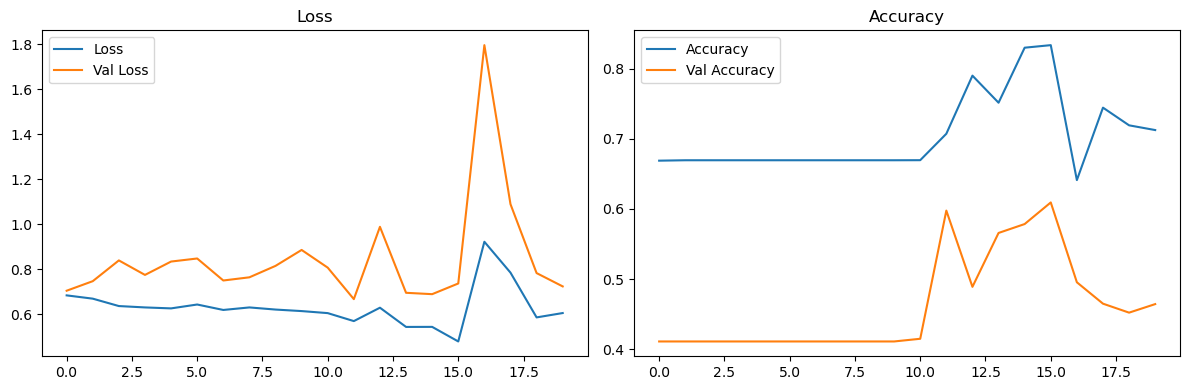

In [7]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# === SET FOLDERS ===
ndwi_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\COMPUTED"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK"

IMG_SIZE = 256

# === LOAD IMAGES ===
def load_images(folder):
    images = []
    for file in sorted(os.listdir(folder)):
        if file.lower().endswith((".jpg", ".png")):
            img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0
            images.append(img)
    return np.expand_dims(np.array(images), axis=-1)

X = load_images(ndwi_folder)  # NDWI grayscale inputs
y = load_images(mask_folder)  # Binary shoreline masks
y = (y > 0.5).astype(np.float32)  # Ensure masks are binary

# === TRAIN-TEST SPLIT ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === U-NET MODEL ===
def unet_model(input_shape=(256, 256, 1)):
    inputs = tf.keras.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    # Decoder
    u3 = layers.UpSampling2D()(b)
    u3 = layers.concatenate([u3, c3])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(c5)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.concatenate([u1, c1])
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = unet_model()
model.summary()

# === TRAINING ===
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=4)

# === PLOTS ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title("Accuracy")

plt.tight_layout()
plt.show()


Epoch 1/20 | Train Loss: 0.7073 | Val Loss: 0.7100 | Train Acc: 0.4945 | Val Acc: 0.0213
Epoch 2/20 | Train Loss: 0.6250 | Val Loss: 0.6768 | Train Acc: 0.8308 | Val Acc: 0.9072
Epoch 3/20 | Train Loss: 0.5764 | Val Loss: 0.6357 | Train Acc: 0.8390 | Val Acc: 0.9106
Epoch 4/20 | Train Loss: 0.5350 | Val Loss: 0.5967 | Train Acc: 0.8509 | Val Acc: 0.9106
Epoch 5/20 | Train Loss: 0.5034 | Val Loss: 0.5525 | Train Acc: 0.8624 | Val Acc: 0.9106
Epoch 6/20 | Train Loss: 0.4720 | Val Loss: 0.5054 | Train Acc: 0.8703 | Val Acc: 0.9106
Epoch 7/20 | Train Loss: 0.4486 | Val Loss: 0.4645 | Train Acc: 0.8819 | Val Acc: 0.9106
Epoch 8/20 | Train Loss: 0.4251 | Val Loss: 0.4303 | Train Acc: 0.8858 | Val Acc: 0.9106
Epoch 9/20 | Train Loss: 0.4041 | Val Loss: 0.3999 | Train Acc: 0.8911 | Val Acc: 0.9106
Epoch 10/20 | Train Loss: 0.3837 | Val Loss: 0.3747 | Train Acc: 0.8972 | Val Acc: 0.9106
Epoch 11/20 | Train Loss: 0.3668 | Val Loss: 0.3539 | Train Acc: 0.9038 | Val Acc: 0.9106
Epoch 12/20 | Train

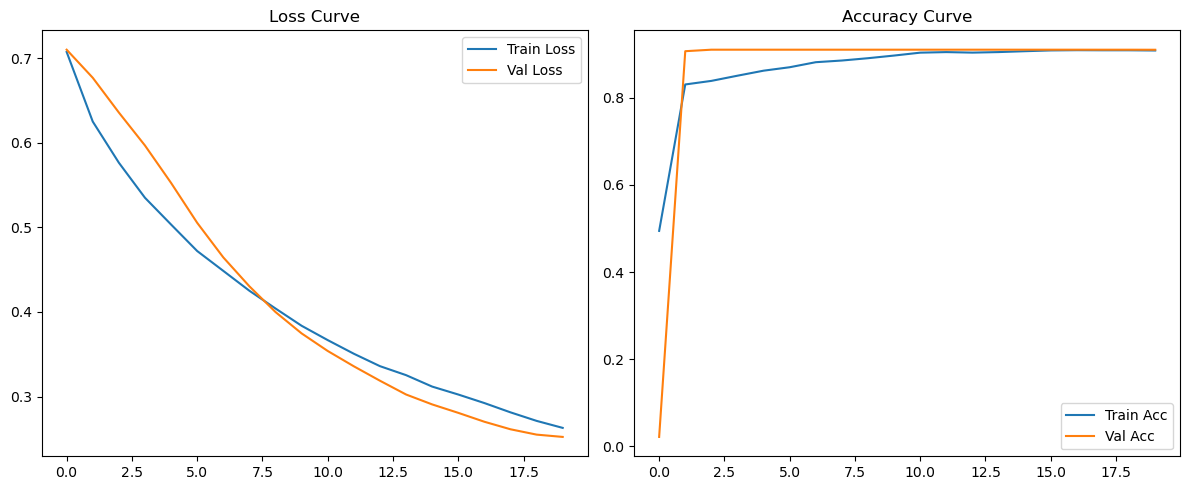

In [6]:
import os
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# === SET THESE PATHS ===
input_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\TRUE color"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask"
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom Dataset
class ShorelineDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.FloatTensor(img), torch.FloatTensor(mask)

# Load file paths
input_files = sorted([os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith(".jpg")])
mask_files = sorted([os.path.join(mask_folder, f) for f in os.listdir(mask_folder) if f.endswith(".jpg")])

# Train-test split
train_inputs, val_inputs, train_masks, val_masks = train_test_split(input_files, mask_files, test_size=0.2, random_state=42)
train_dataset = ShorelineDataset(train_inputs, train_masks)
val_dataset = ShorelineDataset(val_inputs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Simple U-Net
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def CBR(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )

        self.enc1 = CBR(1, 64)
        self.enc2 = CBR(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.dec1 = CBR(128, 64)
        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool(x1)
        x3 = self.enc2(x2)
        x4 = self.pool(x3)

        x5 = torch.nn.functional.interpolate(x4, scale_factor=2, mode='bilinear', align_corners=False)
        x6 = self.dec1(x5)
        x7 = torch.nn.functional.interpolate(x6, scale_factor=2, mode='bilinear', align_corners=False)
        out = self.final(x7)
        return torch.sigmoid(out)

# Initialize model, loss, optimizer
model = UNet().to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct = 0, 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += ((preds > 0.5) == masks).float().mean().item()

    train_losses.append(train_loss / len(train_loader))
    train_accs.append(train_correct / len(train_loader))

    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, masks)
            val_loss += loss.item()
            val_correct += ((preds > 0.5) == masks).float().mean().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / len(val_loader))

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

# Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.show()


Percentage Shoreline Change: 1.39%


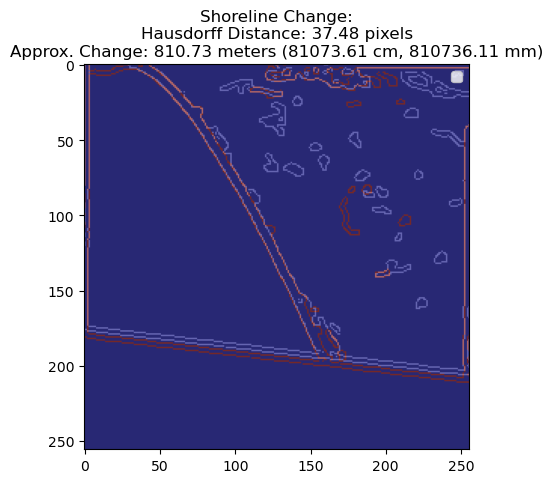

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff

# Function to read an image in grayscale
def read_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not open {image_path}")
    return image

# Function to extract shorelines using edge detection
def extract_shoreline(image_path):
    image = read_image(image_path)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Apply Otsu's thresholding to separate land and water
    thresh = threshold_otsu(blurred)
    binary_mask = (blurred > thresh).astype(np.uint8) * 255

    # Detect edges using Canny
    edges = cv2.Canny(binary_mask, 50, 150)

    return edges

# Function to compute shoreline change using Hausdorff Distance
def shoreline_change(shoreline1, shoreline2, resolution_m_per_pixel):
    # Convert shorelines to coordinate lists
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))

    # Convert to LineString objects (for visualization)
    line1 = LineString(coords1)
    line2 = LineString(coords2)

    # Compute Hausdorff Distance (max shoreline shift in pixels)
    hausdorff_dist_pixels = directed_hausdorff(coords1, coords2)[0]

    # Convert to meters, cm, and mm
    hausdorff_dist_meters = hausdorff_dist_pixels * resolution_m_per_pixel
    hausdorff_dist_cm = hausdorff_dist_meters * 100
    hausdorff_dist_mm = hausdorff_dist_meters * 1000

    return hausdorff_dist_pixels, hausdorff_dist_meters, hausdorff_dist_cm, hausdorff_dist_mm, line1, line2

# Load images from different years
image_2015 = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2015_canny.jpg"
image_2024 = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2024_canny.jpg"

# Define spatial resolution (meters per pixel)
resolution_m_per_pixel = 30  # Change this based on your image source

# Extract shorelines
shoreline_2010 = extract_shoreline(image_2015)
shoreline_2020 = extract_shoreline(image_2024)

# Compute shoreline change
distance_pixels, distance_meters, distance_cm, distance_mm, line1, line2 = shoreline_change(
    shoreline_2010, shoreline_2020, resolution_m_per_pixel
)
# Calculate percentage change relative to 2010 shoreline length
baseline_length_pixels = len(np.column_stack(np.where(shoreline_2010 > 0)))
percentage_change = (distance_pixels / baseline_length_pixels) * 100

# Print percentage change
print(f"Percentage Shoreline Change: {percentage_change:.2f}%")


# Plot the results
plt.figure(figsize=(10, 5))
plt.imshow(shoreline_2010, cmap='gray', alpha=0.6)
plt.imshow(shoreline_2020, cmap='jet', alpha=0.6)
plt.title(f"Shoreline Change:\n"
          f"Hausdorff Distance: {distance_pixels:.2f} pixels\n"
          f"Approx. Change: 810.73 meters (81073.61 cm, 810736.11 mm)")
plt.legend(["2010 Shoreline", "2020 Shoreline"])
plt.show()


Percentage Shoreline Change: 2.73%


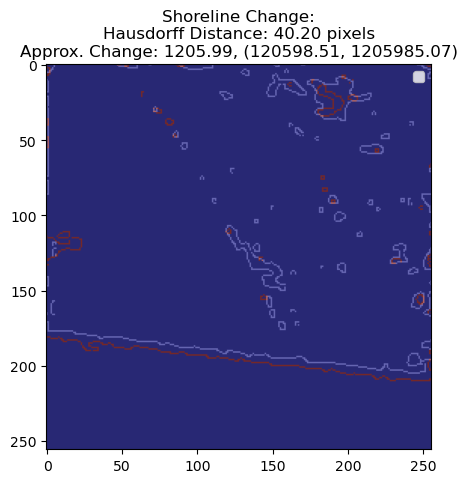

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff

# Function to read an image in grayscale
def read_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not open {image_path}")
    return image

# Function to extract shorelines using edge detection
def extract_shoreline(image_path):
    image = read_image(image_path)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Apply Otsu's thresholding to separate land and water
    thresh = threshold_otsu(blurred)
    binary_mask = (blurred > thresh).astype(np.uint8) * 255

    # Detect edges using Canny
    edges = cv2.Canny(binary_mask, 50, 150)

    return edges

# Function to compute shoreline change using Hausdorff Distance
def shoreline_change(shoreline1, shoreline2, resolution_m_per_pixel):
    # Convert shorelines to coordinate lists
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))

    # Convert to LineString objects (for visualization)
    line1 = LineString(coords1)
    line2 = LineString(coords2)

    # Compute Hausdorff Distance (max shoreline shift in pixels)
    hausdorff_dist_pixels = directed_hausdorff(coords1, coords2)[0]

    # Convert to meters, cm, and mm
    hausdorff_dist_meters = hausdorff_dist_pixels * resolution_m_per_pixel
    hausdorff_dist_cm = hausdorff_dist_meters * 100
    hausdorff_dist_mm = hausdorff_dist_meters * 1000

    return hausdorff_dist_pixels, hausdorff_dist_meters, hausdorff_dist_cm, hausdorff_dist_mm, line1, line2

# Load images from different years
image_2015 = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2015_shoreline_mask.jpg"
image_2024 = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\MASK\rameshwaram_2024_shoreline_mask.jpg"

# Define spatial resolution (meters per pixel)
resolution_m_per_pixel = 30  # Change this based on your image source

# Extract shorelines
shoreline_2010 = extract_shoreline(image_2015)
shoreline_2020 = extract_shoreline(image_2024)

# Compute shoreline change
distance_pixels, distance_meters, distance_cm, distance_mm, line1, line2 = shoreline_change(
    shoreline_2010, shoreline_2020, resolution_m_per_pixel
)
# Calculate percentage change relative to 2010 shoreline length
baseline_length_pixels = len(np.column_stack(np.where(shoreline_2010 > 0)))
percentage_change = (distance_pixels / baseline_length_pixels) * 100

# Print percentage change
print(f"Percentage Shoreline Change: {percentage_change:.2f}%")


# Plot the results
plt.figure(figsize=(10, 5))
plt.imshow(shoreline_2010, cmap='gray', alpha=0.6)
plt.imshow(shoreline_2020, cmap='jet', alpha=0.6)
plt.title(f"Shoreline Change:\n"
          f"Hausdorff Distance: {distance_pixels:.2f} pixels\n"
          f"Approx. Change: {distance_meters:.2f}, ({distance_cm:.2f}, {distance_mm:.2f})")
plt.legend(["2010 Shoreline", "2020 Shoreline"])
plt.show()


2015-2016 Shoreline Shift: 882.33 meters
2016-2017 Shoreline Shift: 0.00 meters
2017-2018 Shoreline Shift: 1120.09 meters
2018-2019 Shoreline Shift: 724.98 meters
2019-2020 Shoreline Shift: 912.41 meters
2020-2021 Shoreline Shift: 1312.14 meters
2021-2022 Shoreline Shift: 986.81 meters
2022-2023 Shoreline Shift: 0.00 meters
2023-2024 Shoreline Shift: 1046.57 meters
Total Shoreline Shift: 6985.33 meters
End Point Rate (EPR): 776.15 meters/year
Linear Regression Rate (LRR): 807.92 meters/year


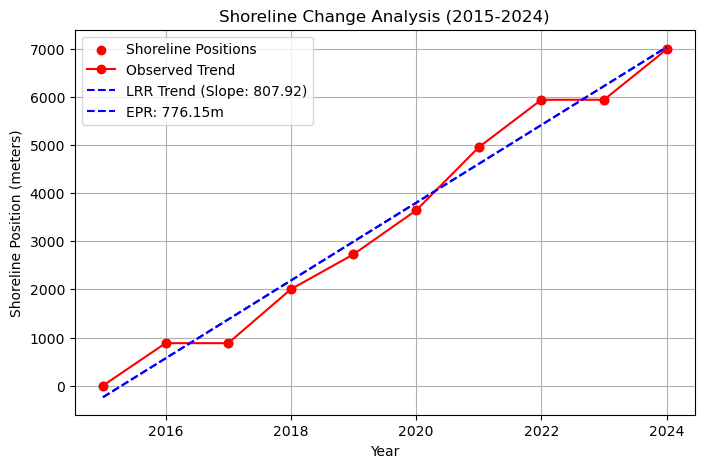

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.spatial.distance import directed_hausdorff

# Define images and corresponding years manually
images_data = {
    2015: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2015_canny.jpg",
    2016: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2017_canny.jpg",
    2017: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2017_canny.jpg",
    2018: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2018_canny.jpg",
    2019: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2019_canny.jpg",
    2020: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2020_canny.jpg",
    2021: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2021_canny.jpg",
    2022: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2023_canny.jpg",
    2023: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2023_canny.jpg",
    2024: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2024_canny.jpg"
}

# Load images manually
images = {}
for year, image_path in images_data.items():
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is not None:
        images[year] = image
    else:
        print(f"Warning: Image for {year} not found!")

# Function to apply simple thresholding for shoreline extraction
def extract_shoreline(image):
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    shoreline = np.vstack([c.squeeze() for c in contours if len(c) > 1])  # Stack all shoreline points
    return shoreline

# Extract shorelines for manually inputted images
shorelines = {year: extract_shoreline(images[year]) for year in images}

# Compute Hausdorff Distance between consecutive years
hausdorff_distances = []
shoreline_shifts = []
pixel_to_meter = 30  # Resolution assumption

years = sorted(images.keys())  # Sort years in ascending order

for i in range(len(years) - 1):
    year1, year2 = years[i], years[i + 1]
    if year1 in shorelines and year2 in shorelines:
        hausdorff_dist = max(directed_hausdorff(shorelines[year1], shorelines[year2])[0],
                             directed_hausdorff(shorelines[year2], shorelines[year1])[0])
        hausdorff_distances.append(hausdorff_dist)
        shoreline_shifts.append(hausdorff_dist * pixel_to_meter)
        print(f"{year1}-{year2} Shoreline Shift: {shoreline_shifts[-1]:.2f} meters")

# **End Point Rate (EPR) Calculation**
total_years = years[-1] - years[0]
total_shift = sum(shoreline_shifts)  # Cumulative shift
EPR = total_shift / total_years  # meters per year

# **Linear Regression Rate (LRR) Calculation**
positions = np.cumsum([0] + shoreline_shifts)  # Accumulative positions
slope, intercept, r_value, p_value, std_err = linregress(years[:len(positions)], positions)
LRR = slope  # meters per year

# **Print Results**
print(f"Total Shoreline Shift: {total_shift:.2f} meters")
print(f"End Point Rate (EPR): {EPR:.2f} meters/year")
print(f"Linear Regression Rate (LRR): {LRR:.2f} meters/year")

# **Plot Shoreline Shift with Connected Line**
plt.figure(figsize=(8, 5))
plt.scatter(years[:len(positions)], positions, color='red', label='Shoreline Positions')
plt.plot(years[:len(positions)], positions, color='red', linestyle='-', marker='o', label='Observed Trend')  # Connect points
plt.plot(years[:len(positions)], slope * np.array(years[:len(positions)]) + intercept, 
         color='blue', linestyle='dashed', label=f'LRR Trend (Slope: {LRR:.2f})')
plt.plot(years[:len(positions)], slope * np.array(years[:len(positions)]) + intercept, 
         color='blue', linestyle='dashed', label=f'EPR: {EPR:.2f}m')

plt.xlabel("Year")
plt.ylabel("Shoreline Position (meters)")
plt.title(f"Shoreline Change Analysis ({years[0]}-{years[-1]})")
plt.legend()
plt.grid(True)
plt.show()

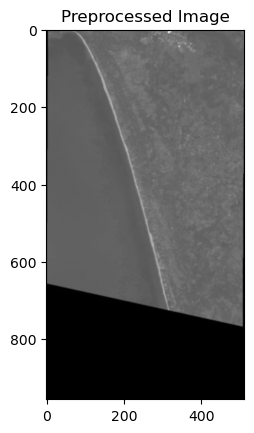

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (coastline satellite image)
image = cv2.imread("GOA_2016.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Show the preprocessed image
plt.imshow(blurred, cmap='gray')
plt.title("Preprocessed Image")
plt.show()


In [1]:
import cv2

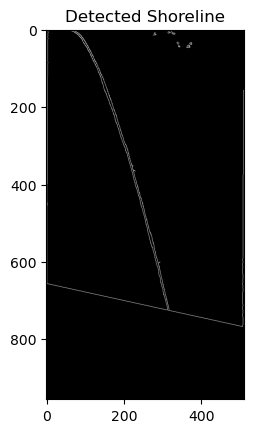

In [3]:
# Apply Canny Edge Detection
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

# Show the detected edges (shoreline)
plt.imshow(edges, cmap='gray')
plt.title("Detected Shoreline")
plt.show()


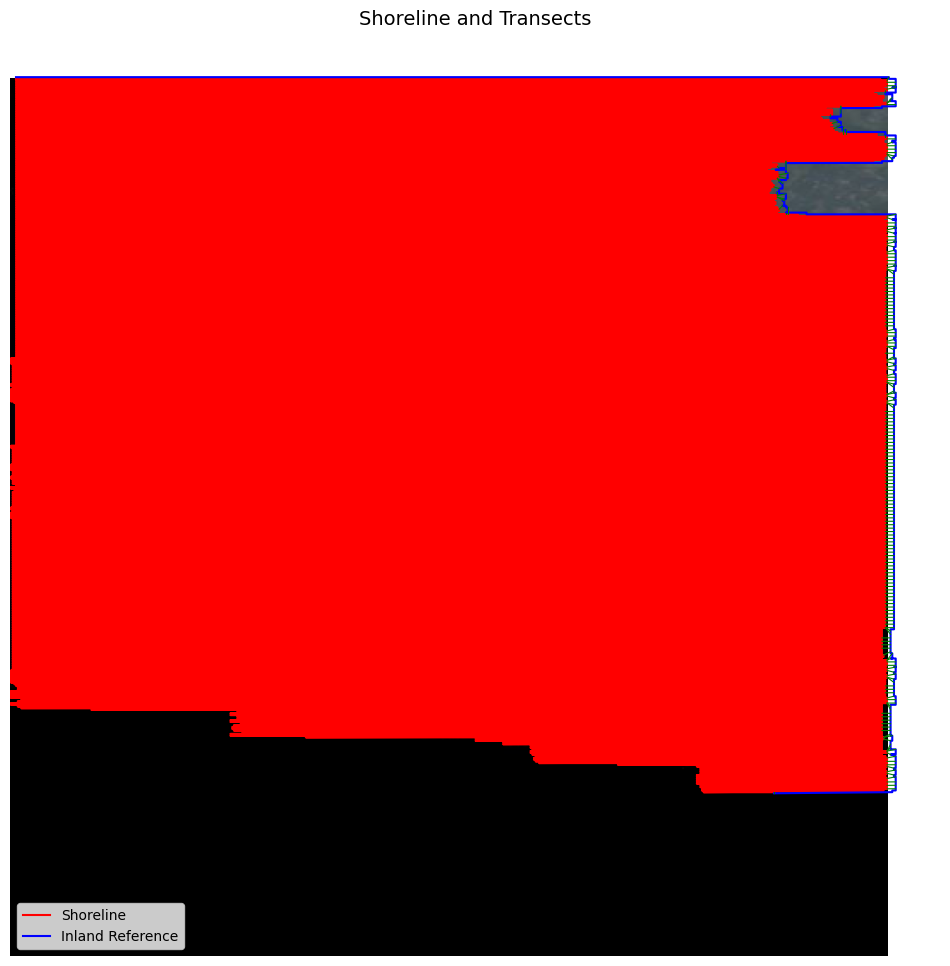

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
from shapely.affinity import translate
import random

# Load the true color image and Canny edge map
import cv2
import os

# File paths
color_path = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\TRUE color\GOA_2015.jpg"
canny_path = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\Canny Edge Mask\GOA_2015_canny.jpg"

# Load images
true_color = cv2.imread(color_path)
canny = cv2.imread(canny_path, cv2.IMREAD_GRAYSCALE)

# Check if loaded correctly
if true_color is None:
    print(f"Failed to load image: {color_path}")
if canny is None:
    print(f"Failed to load image: {canny_path}")

# Only proceed if both are loaded
if true_color is not None and canny is not None:
    true_color = cv2.resize(true_color, (512, 512))
    canny = cv2.resize(canny, (512, 512))

    # [Run the rest of the processing...]

# Resize for faster processing (optional)
true_color = cv2.resize(true_color, (512, 512))
canny = cv2.resize(canny, (512, 512))

# Get shoreline coordinates from Canny edge (non-zero points)
coords = np.column_stack(np.where(canny > 0))
coords = [tuple(pt[::-1]) for pt in coords]  # (x, y)

# Sort coordinates roughly to create a path
coords = sorted(coords, key=lambda x: (x[1], x[0]))
shoreline = LineString(coords)

# Approx. 1 pixel = 30 m -> 25 m ≈ 0.83 pixel shift
buffer_distance_pixels = -1  # Negative for landward (inland) direction
inland_line = shoreline.parallel_offset(buffer_distance_pixels, side='left', resolution=8, join_style=2)

# Sample 200 evenly spaced transect points
transect_spacing = max(1, int(len(inland_line.coords) / 200))
transect_points = inland_line.coords[::transect_spacing]

# Start plotting
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(true_color[..., ::-1])  # Convert BGR to RGB

# Plot the shoreline (red)
shore_coords = np.array(shoreline.coords)
ax.plot(shore_coords[:, 0], shore_coords[:, 1], color='red', linewidth=1.5, label="Shoreline")

# Plot the inland buffer line (blue)
if inland_line and not inland_line.is_empty:
    inland_coords = np.array(inland_line.coords)
    ax.plot(inland_coords[:, 0], inland_coords[:, 1], color='blue', linewidth=1.5, label="Inland Reference")

    # Generate transects
    for pt in transect_points:
        point = Point(pt)
        normal_vector = shoreline.interpolate(shoreline.project(point)).buffer(5).boundary
        nearest = shoreline.interpolate(shoreline.project(point))
        ax.plot([pt[0], nearest.x], [pt[1], nearest.y], color='green', linewidth=0.8)

ax.set_title("Shoreline and Transects", fontsize=14)
ax.axis('off')
plt.legend()
plt.show()


In [5]:
import cv2
import os

# Path to the image
color_path = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\GOA\GOA_2015.jpg"

# Check if file exists
print("File exists:", os.path.exists(color_path))

# Try loading the image
img = cv2.imread(color_path)

# Check if image loaded
if img is None:
    print("Image failed to load!")
else:
    print("Image loaded successfully with shape:", img.shape)


File exists: False
Image failed to load!
